# Active-demand evidence and common forecast origins

## Thresholds used

- **Upstream input filter:** FCM product-store series require at least 30 active days and 10 positive-demand days; Pseudo series require at least 120 active days and 30 positive-demand days.
- **FCM calibration grid:** active-day windows `W = [31, 61, 91, 121, 151, 181]` and minimum positive-demand counts `k = [10, 15, 20, 25, 30]`.
- **Later-only reference cohort:** observations after active day 181; at least 24 later active days and at least 2 later positive-demand days.
- **Acceptable `(W, k)` pair:** at least 80% FCM series coverage and at least 90% retention of the reference cohort; the smallest acceptable `W` and then `k` is selected. On the current data this is `(W, k) = (91, 10)`.
- **Diagnostic only:** the 60% demand-class agreement target is reported but is not a hard selection threshold.
- **Forecast origins:** the first common Monday must reach at least 80% FCM eligibility under the selected `(W, k)` rule; later origins are 14 calendar days apart and use a 7-calendar-day test horizon.
- **ADI–CV² classes:** ADI cutoff 1.32 and CV² cutoff 0.49.
- **Pseudo validation:** 95% eligibility is the “near-total” check; the final validation also requires finite Pseudo CV² values and more than one represented demand class.

This notebook prepares the daily `ARTIKEL_ID` x `MARKT_ID` series for a shared forecast evaluation. The target is kilograms of the final article sold at the counter. Sourcing changes the length and density of the observed histories, so the pooled daily data are split into two mutually exclusive groups:

- **FCM:** internal production delivered ready to sell (`is_fcm = True`);
- **Pseudo:** raw material ordered and processed in-store into final sales articles (`is_pseudo = True`, `is_fcm = False`).

The descriptive whole-history distributions and minimum-history cutoff are handled in `00_03_minimum_demand.ipynb`. This notebook estimates the minimum-information rule $(W,k)$ with the older FCM calibration idea: compare the first $W$ active observations with a fixed later-only reference segment and choose the smallest acceptable pair. It then switches back to the newer evaluation design: forecast origins are common Mondays, training data are all rows with `DATE < origin`, and each test window is the seven-calendar-day interval starting at the origin. Closed days are not imputed.

In [8]:
from pathlib import Path
from io import BytesIO
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
GROUP_ORDER = ["FCM", "Pseudo"]
GROUP_COLORS = {"FCM": "#c4513b", "Pseudo": "#d7a84b", "Pooled": "#7d8588"}
CATEGORY_LABELS = {890: "890 meat", 900: "900 sausages"}
MEASURE_LABELS = {
    "calendar_span_days": "Calendar span: first through last observation (days)",
    "active_days": "Observed open days",
    "demand_days": "Positive-demand days",
    "demand_day_ratio": "Demand days / observed open days",
}

# Candidate grid and reference minimum retained from the OLD joint-calibration analysis.
CALIBRATION_GROUP = "FCM"
WINDOW_CANDIDATES = [31, 61, 91, 121, 151, 181]
MIN_DEMAND_CANDIDATES = [10, 15, 20, 25, 30]
REFERENCE_MIN_ACTIVE_DAYS = 24
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

# Calendar evaluation design from the NEW notebook.
ORIGIN_SPACING_DAYS = 14
FORECAST_HORIZON_CALENDAR_DAYS = 7

# Operating-quality requirements are declared before inspecting the selected pair.
MIN_SERIES_COVERAGE = 0.8
MIN_REFERENCE_ELIGIBLE_SHARE = 0.9
CLASS_AGREEMENT_TARGET = 0.6
LONG_GROUP_NEAR_TOTAL_RATE = 0.95

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".."), Path(".")] if (p / "src").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the project root containing src/.")

DATA_DIR = PROJECT_ROOT / "data" / "interim" / "transactions_dst_daily_min_demand_no_outliers"
parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")
DATA_GLOB = str(DATA_DIR / "*.parquet")

con = duckdb.connect()
con.execute("PRAGMA threads=4")

def display_figure(fig, dpi=120):
    """Embed an Agg figure in notebook output and release its memory."""
    figure_buffer = BytesIO()
    fig.savefig(figure_buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=figure_buffer.getvalue()))
    plt.close(fig)

def five_number_summary(frame, by):
    """Five-number summaries for the shared history/evidence measures."""
    parts = []
    for measure in MEASURE_LABELS:
        result = (
            frame.groupby(by, observed=True)[measure]
            .agg(
                series="size",
                minimum="min",
                q25=lambda values: values.quantile(0.25),
                median="median",
                q75=lambda values: values.quantile(0.75),
                maximum="max",
            )
            .reset_index()
        )
        result["measure"] = measure
        parts.append(result)
    return pd.concat(parts, ignore_index=True)


## Data basis and sourcing-group construction

The source flags define origin; product category does not. FCM takes precedence in the `CASE` expression, while the audit below requires that `is_fcm` and `is_pseudo` never overlap. `WGR_ID` is retained separately as the reporting category (890 meat and 900 sausages). The audit also checks null flags, out-of-scope categories, duplicate product-store dates, and series whose sourcing group or category changes through time. A failure stops the notebook because any of these conditions would make group-level histories ambiguous.

A row represents an open day for that product-store series. This is a property of the prepared data, not an inferred seven-day calendar. Consequently, `COUNT(*)` is the effective number of active/open days and `COUNT_IF(demand > 0)` is the number of demand days.


In [9]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW daily_rows AS
SELECT
    ARTIKEL_ID,
    MARKT_ID,
    CAST(DATE AS DATE) AS period,
    CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand,
    is_fcm,
    is_pseudo,
    WGR_ID::INTEGER AS category_id,
    CASE WGR_ID
        WHEN 890 THEN '890 meat'
        WHEN 900 THEN '900 sausages'
    END AS category,
    CASE
        WHEN is_fcm THEN 'FCM'
        WHEN is_pseudo THEN 'Pseudo'
    END AS sourcing_group
FROM read_parquet('{DATA_GLOB}')
WHERE (is_fcm OR is_pseudo)
  AND WGR_ID IN (890, 900)
""")

row_audit = con.execute("""
SELECT
    COUNT(*) AS rows,
    MIN(period) AS first_date,
    MAX(period) AS last_date,
    COUNT_IF(is_fcm IS NULL) AS null_fcm_flags,
    COUNT_IF(is_pseudo IS NULL) AS null_pseudo_flags,
    COUNT_IF(is_fcm AND is_pseudo) AS overlapping_source_flags,
    COUNT_IF(category_id NOT IN (890, 900) OR category_id IS NULL) AS invalid_categories
FROM daily_rows
""").fetchdf()

duplicate_series_dates = con.execute("""
SELECT COUNT(*)
FROM (
    SELECT ARTIKEL_ID, MARKT_ID, period
    FROM daily_rows
    GROUP BY ALL
    HAVING COUNT(*) > 1
)
""").fetchone()[0]

changing_series_attributes = con.execute("""
SELECT COUNT(*)
FROM (
    SELECT ARTIKEL_ID, MARKT_ID
    FROM daily_rows
    GROUP BY ARTIKEL_ID, MARKT_ID
    HAVING COUNT(DISTINCT sourcing_group) > 1
        OR COUNT(DISTINCT category_id) > 1
)
""").fetchone()[0]

row_audit["duplicate_series_dates"] = duplicate_series_dates
row_audit["changing_series_attributes"] = changing_series_attributes
display(row_audit)

audit_failures = row_audit[[
    "null_fcm_flags", "null_pseudo_flags", "overlapping_source_flags",
    "invalid_categories", "duplicate_series_dates", "changing_series_attributes",
]].sum(axis=1).iloc[0]
if audit_failures:
    raise RuntimeError("Source/category audit failed; inspect row_audit before continuing.")

group_category_population = con.execute("""
SELECT
    sourcing_group,
    category,
    COUNT(*) AS rows,
    COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
    COUNT(DISTINCT MARKT_ID) AS stores,
    COUNT(DISTINCT ARTIKEL_ID) AS products,
    SUM(demand) AS total_demand_kg,
    MAX(demand) AS maximum_daily_demand_kg
FROM daily_rows
GROUP BY sourcing_group, category
ORDER BY CASE sourcing_group WHEN 'FCM' THEN 1 WHEN 'Pseudo' THEN 2 ELSE 3 END, category
""").fetchdf()
display(group_category_population.style.format({
    "rows": "{:,.0f}", "series": "{:,.0f}", "stores": "{:,.0f}", "products": "{:,.0f}",
    "total_demand_kg": "{:,.1f}", "maximum_daily_demand_kg": "{:,.1f}",
}))


,rows,first_date,last_date,null_fcm_flags,null_pseudo_flags,overlapping_source_flags,invalid_categories,duplicate_series_dates,changing_series_attributes
0,19934887,2023-07-22,2026-07-21,0.0,0.0,0.0,0.0,0,0


,sourcing_group,category,rows,series,stores,products,total_demand_kg,maximum_daily_demand_kg
0,FCM,890 meat,"29,089",135,82,9,"3,024.9",12.3
1,FCM,900 sausages,"761,675","2,772",189,20,"147,990.0",30.3
2,Pseudo,890 meat,"19,118,384","22,201",192,327,"20,154,536.9",280.0
3,Pseudo,900 sausages,"25,739",61,48,15,"5,798.3",9.0


## 1. Estimating $(W,k)$

The OLD notebook estimated the minimum-information rule on FCM series only. That logic is kept here. For each candidate pair, $W$ is the number of active/open days in the initial origin window and $k$ is the required number of positive-demand days inside those $W$ observations.

The comparison target is a common later-only reference segment. It begins after the largest candidate window, so no reference observation overlaps any candidate origin estimate. A reference series must have at least `REFERENCE_MIN_ACTIVE_DAYS` active days and at least two positive-demand days. Candidate pairs are judged first by FCM population coverage and retention of the fixed reference cohort. Agreement between the initial and later ADI/CV2 demand classes is reported on the same surface as a stability diagnostic. The current FCM data do not reach the OLD notebook's 70% class-agreement target, so that value is kept visible but no longer allowed to make the notebook stop. The selected pair is the smallest acceptable $W$ and then the smallest acceptable $k$ among FCM pairs that pass the coverage and reference-retention gates.

In [10]:
def classify_demand(metrics):
    metrics = metrics.copy()
    metrics["ADI"] = metrics["active_days"] / metrics["demand_days"].replace(0, np.nan)
    metrics["CV2"] = metrics["var_nonzero_demand"] / metrics["mean_nonzero_demand"].pow(2)
    finite = np.isfinite(metrics["ADI"]) & np.isfinite(metrics["CV2"])
    metrics["demand_class"] = np.select(
        [
            finite & (metrics["ADI"] < ADI_CUTOFF) & (metrics["CV2"] < CV2_CUTOFF),
            finite & (metrics["ADI"] < ADI_CUTOFF) & (metrics["CV2"] >= CV2_CUTOFF),
            finite & (metrics["ADI"] >= ADI_CUTOFF) & (metrics["CV2"] < CV2_CUTOFF),
            finite,
        ],
        ["smooth", "erratic", "intermittent", "lumpy"],
        default="undefined",
    )
    return metrics

def compute_demand_metrics(frame):
    metrics = frame.groupby(GROUP_COLS, sort=False).agg(
        active_days=("period", "size"),
        demand_days=("demand", lambda demand: (demand > 0).sum()),
        mean_nonzero_demand=("demand", lambda demand: demand[demand > 0].mean()),
        var_nonzero_demand=("demand", lambda demand: demand[demand > 0].var(ddof=1)),
    )
    return classify_demand(metrics).reset_index()

calibration_periods = con.execute(
    """
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        period,
        demand,
        ROW_NUMBER() OVER (
            PARTITION BY ARTIKEL_ID, MARKT_ID
            ORDER BY period
        ) AS active_day_number
    FROM daily_rows
    WHERE sourcing_group = ?
    ORDER BY ARTIKEL_ID, MARKT_ID, period
    """,
    [CALIBRATION_GROUP],
).fetchdf()
calibration_periods["period"] = pd.to_datetime(calibration_periods["period"])
calibration_periods["active_day_number"] = calibration_periods["active_day_number"].astype(int)

total_calibration_series = calibration_periods[GROUP_COLS].drop_duplicates().shape[0]
total_calibration_stores = calibration_periods["MARKT_ID"].nunique()
total_calibration_products = calibration_periods["ARTIKEL_ID"].nunique()

max_candidate_window = max(WINDOW_CANDIDATES)
reference_data = calibration_periods[
    calibration_periods["active_day_number"] > max_candidate_window
]
reference_metrics = compute_demand_metrics(reference_data)
reference_metrics = reference_metrics[
    (reference_metrics["active_days"] >= REFERENCE_MIN_ACTIVE_DAYS)
    & (reference_metrics["demand_days"] >= 2)
].copy()

reference_summary = reference_metrics[["active_days", "demand_days"]].describe().loc[
    ["count", "min", "25%", "50%", "75%", "max"]
]
print(
    f"{CALIBRATION_GROUP} later-only reference cohort: {len(reference_metrics):,} "
    f"of {total_calibration_series:,} series."
)
display(reference_summary)

joint_rows = []
for window_size in WINDOW_CANDIDATES:
    origin_data = calibration_periods[
        calibration_periods["active_day_number"] <= window_size
    ]
    origin_metrics = compute_demand_metrics(origin_data)
    origin_metrics = origin_metrics[origin_metrics["active_days"] == window_size]

    for min_demand_days in MIN_DEMAND_CANDIDATES:
        eligible = origin_metrics[origin_metrics["demand_days"] >= min_demand_days]
        comparison = eligible[[*GROUP_COLS, "ADI", "CV2", "demand_class"]].merge(
            reference_metrics[[*GROUP_COLS, "ADI", "CV2", "demand_class"]],
            on=GROUP_COLS,
            how="inner",
            suffixes=("_origin", "_reference"),
        )
        comparison["class_match"] = (
            comparison["demand_class_origin"] == comparison["demand_class_reference"]
        )
        class_agreement_by_reference = comparison.groupby(
            "demand_class_reference", observed=True
        )["class_match"].mean()

        joint_rows.append({
            "window_active_days": window_size,
            "min_demand_days": min_demand_days,
            "eligible_series": len(eligible),
            "series_coverage": len(eligible) / total_calibration_series,
            "store_coverage": (
                eligible["MARKT_ID"].nunique() / total_calibration_stores
                if total_calibration_stores else np.nan
            ),
            "product_coverage": (
                eligible["ARTIKEL_ID"].nunique() / total_calibration_products
                if total_calibration_products else np.nan
            ),
            "reference_eligible_series": len(comparison),
            "reference_eligible_share": (
                len(comparison) / len(reference_metrics) if len(reference_metrics) else np.nan
            ),
            "class_agreement": comparison["class_match"].mean(),
            "macro_class_agreement": class_agreement_by_reference.mean(),
            "median_absolute_ADI_error": (
                comparison["ADI_origin"] - comparison["ADI_reference"]
            ).abs().median(),
            "median_absolute_CV2_error": (
                comparison["CV2_origin"] - comparison["CV2_reference"]
            ).abs().median(),
        })

joint_calibration_results = pd.DataFrame(joint_rows)
joint_calibration_results["meets_class_agreement_target"] = (
    joint_calibration_results["class_agreement"] >= CLASS_AGREEMENT_TARGET
)
display(joint_calibration_results.style.format({
    "eligible_series": "{:,.0f}",
    "series_coverage": "{:.1%}",
    "store_coverage": "{:.1%}",
    "product_coverage": "{:.1%}",
    "reference_eligible_series": "{:,.0f}",
    "reference_eligible_share": "{:.1%}",
    "class_agreement": "{:.1%}",
    "macro_class_agreement": "{:.1%}",
    "median_absolute_ADI_error": "{:.2f}",
    "median_absolute_CV2_error": "{:.2f}",
}))

acceptable = joint_calibration_results[
    (joint_calibration_results["series_coverage"] >= MIN_SERIES_COVERAGE)
    & (joint_calibration_results["reference_eligible_share"] >= MIN_REFERENCE_ELIGIBLE_SHARE)
].sort_values(["window_active_days", "min_demand_days"])

if acceptable.empty:
    raise RuntimeError(
        "No FCM (W, k) pair satisfies the coverage and reference-retention constraints. "
        "Inspect the result surface before changing the candidate grid or thresholds."
    )

selected_pair = acceptable.iloc[0]
DEFAULT_MIN_TRAIN_SIZE = int(selected_pair["window_active_days"])
MIN_DEMAND_PERIODS_UNTIL_ORIGIN = int(selected_pair["min_demand_days"])
print("FCM calibration constraints:")
print(
    f"  FCM coverage >= {MIN_SERIES_COVERAGE:.0%}; "
    f"reference eligibility >= {MIN_REFERENCE_ELIGIBLE_SHARE:.0%}. "
    f"Class agreement target shown for diagnosis: {CLASS_AGREEMENT_TARGET:.0%}."
)
print(
    f"Selected FCM-derived (W, k) = ({DEFAULT_MIN_TRAIN_SIZE}, "
    f"{MIN_DEMAND_PERIODS_UNTIL_ORIGIN}); "
    f"class agreement = {selected_pair['class_agreement']:.1%}."
)
if not bool(selected_pair["meets_class_agreement_target"]):
    print(
        "Note: no selected-pair hard stop is applied for class agreement; "
        "the FCM surface stays visible for interpretation."
    )
display(acceptable.head(10).style.format({
    "eligible_series": "{:,.0f}",
    "series_coverage": "{:.1%}",
    "store_coverage": "{:.1%}",
    "product_coverage": "{:.1%}",
    "reference_eligible_series": "{:,.0f}",
    "reference_eligible_share": "{:.1%}",
    "class_agreement": "{:.1%}",
    "macro_class_agreement": "{:.1%}",
    "median_absolute_ADI_error": "{:.2f}",
    "median_absolute_CV2_error": "{:.2f}",
}))

def plot_calibration_heatmaps():
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
    heatmap_specs = [
        ("series_coverage", "FCM population coverage", ".0%"),
        ("reference_eligible_share", "Reference cohort retained", ".0%"),
        ("class_agreement", "Later class agreement", ".0%"),
    ]
    for ax, (measure, title, annotation_format) in zip(axes, heatmap_specs):
        matrix = joint_calibration_results.pivot(
            index="min_demand_days", columns="window_active_days", values=measure
        )
        sns.heatmap(
            matrix, annot=True, fmt=annotation_format, cmap="YlGnBu",
            vmin=0, vmax=1, ax=ax, cbar=False
        )
        selected_column = list(matrix.columns).index(DEFAULT_MIN_TRAIN_SIZE)
        selected_row = list(matrix.index).index(MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
        ax.add_patch(plt.Rectangle(
            (selected_column, selected_row), 1, 1,
            fill=False, edgecolor="#d62728", linewidth=3, clip_on=False
        ))
        ax.set_title(title)
        ax.set_xlabel("Origin window W (active days)")
        ax.set_ylabel("Minimum demand days k")
    display_figure(fig)

selected_window = calibration_periods[
    calibration_periods["active_day_number"] <= DEFAULT_MIN_TRAIN_SIZE
]
selected_origin_metrics = compute_demand_metrics(selected_window)
selected_origin_metrics = selected_origin_metrics[
    (selected_origin_metrics["active_days"] == DEFAULT_MIN_TRAIN_SIZE)
    & (selected_origin_metrics["demand_days"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
]
selected_comparison = selected_origin_metrics[[*GROUP_COLS, "demand_class"]].merge(
    reference_metrics[[*GROUP_COLS, "demand_class"]],
    on=GROUP_COLS,
    how="inner",
    suffixes=("_origin", "_reference"),
)
selected_confusion = pd.crosstab(
    selected_comparison["demand_class_reference"],
    selected_comparison["demand_class_origin"],
    rownames=["Later reference"],
    colnames=["First W-day window"],
)
selected_confusion_share = pd.crosstab(
    selected_comparison["demand_class_reference"],
    selected_comparison["demand_class_origin"],
    rownames=["Later reference"],
    colnames=["First W-day window"],
    normalize="index",
)
print("Selected-pair class confusion, counts:")
display(selected_confusion)
print("Selected-pair class confusion, row shares:")
display(selected_confusion_share.style.format("{:.1%}"))

FCM later-only reference cohort: 2,069 of 2,907 series.


,active_days,demand_days
count,2069.0,2069.0
min,26.0,2.0
25%,111.0,17.0
50%,157.0,46.0
75%,167.0,99.0
max,253.0,193.0


,window_active_days,min_demand_days,eligible_series,series_coverage,store_coverage,product_coverage,reference_eligible_series,reference_eligible_share,class_agreement,macro_class_agreement,median_absolute_ADI_error,median_absolute_CV2_error,meets_class_agreement_target
0,31,10,"1,731",59.5%,98.9%,89.7%,"1,189",57.5%,52.2%,48.2%,0.39,0.15,False
1,31,15,"1,109",38.1%,94.2%,79.3%,785,37.9%,49.7%,47.6%,0.20,0.13,False
2,31,20,611,21.0%,84.2%,62.1%,470,22.7%,47.0%,45.6%,0.13,0.11,False
3,31,25,239,8.2%,56.8%,44.8%,206,10.0%,53.9%,32.2%,0.08,0.10,False
4,31,30,36,1.2%,15.3%,31.0%,34,1.6%,76.5%,48.7%,0.08,0.06,True
5,61,10,"2,335",80.3%,100.0%,86.2%,"1,670",80.7%,55.0%,50.3%,0.65,0.16,False
6,61,15,"1,870",64.3%,98.9%,75.9%,"1,341",64.8%,55.7%,51.2%,0.40,0.14,False
7,61,20,"1,550",53.3%,98.9%,69.0%,"1,119",54.1%,55.6%,51.8%,0.29,0.13,False
8,61,25,"1,261",43.4%,96.8%,69.0%,916,44.3%,56.3%,53.1%,0.20,0.12,False
9,61,30,971,33.4%,93.2%,58.6%,734,35.5%,54.8%,52.7%,0.14,0.11,False


FCM calibration constraints:
  FCM coverage >= 80%; reference eligibility >= 90%. Class agreement target shown for diagnosis: 60%.
Selected FCM-derived (W, k) = (91, 10); class agreement = 56.5%.
Note: no selected-pair hard stop is applied for class agreement; the FCM surface stays visible for interpretation.


,window_active_days,min_demand_days,eligible_series,series_coverage,store_coverage,product_coverage,reference_eligible_series,reference_eligible_share,class_agreement,macro_class_agreement,median_absolute_ADI_error,median_absolute_CV2_error,meets_class_agreement_target
10,91,10,"2,559",88.0%,100.0%,75.9%,"1,864",90.1%,56.5%,51.8%,0.72,0.16,False
15,121,10,"2,666",91.7%,100.0%,79.3%,"1,927",93.1%,58.3%,52.9%,0.66,0.16,False


Selected-pair class confusion, counts:


First W-day window,erratic,intermittent,lumpy,smooth
Later reference,,,,
erratic,37,9,30,20
intermittent,11,419,409,17
lumpy,16,183,493,9
smooth,52,25,30,104


Selected-pair class confusion, row shares:


First W-day window,erratic,intermittent,lumpy,smooth
Later reference,,,,
erratic,38.5%,9.4%,31.2%,20.8%
intermittent,1.3%,48.9%,47.8%,2.0%
lumpy,2.3%,26.1%,70.3%,1.3%
smooth,24.6%,11.8%,14.2%,49.3%


## 2. Common calendar forecast origins and training windows

The selected $(W,k)$ pair is now applied to calendric forecast origins. The first candidate is the first Monday on or after all three sourcing groups are present. The notebook then walks forward Monday by Monday and starts the evaluation at the first date where the fixed FCM-calibrated rule reaches the same population-coverage requirement on FCM using only rows before that Monday.

From that first origin onward, origins are spaced by 14 calendar days. At every origin, the training window is expanding and calendric: all rows with `DATE < origin`. The test window is the seven-calendar-day interval beginning at the origin. Only rows actually present inside that interval are scored.

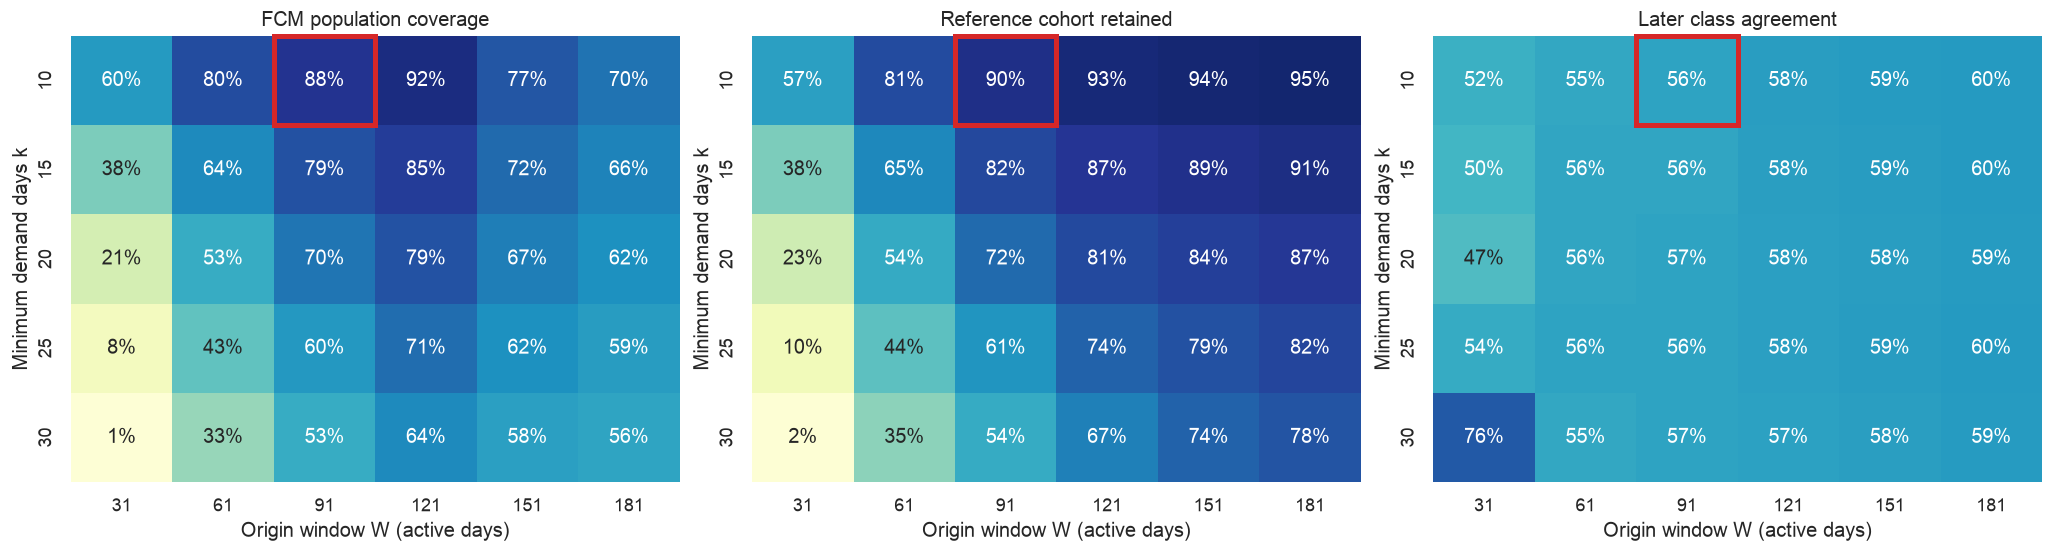

Number of 14-day-spaced calendar origins for selected (W, k)=(91, 10): 14.


,sourcing_group,first_date
1,FCM,2025-04-17
0,Pseudo,2023-07-22


Calendar stopping rule for the first origin:


,candidate_monday,known_fcm_series,eligible_fcm_series,fcm_eligibility_rate,fcm_median_active_days,fcm_median_demand_days
0,2025-04-21 00:00:00,58,0,0.0%,1.0,1.0
1,2025-04-28 00:00:00,127,0,0.0%,5.0,3.0
2,2025-05-05 00:00:00,143,0,0.0%,10.0,5.0
3,2025-05-12 00:00:00,327,0,0.0%,4.0,2.0
4,2025-05-19 00:00:00,424,0,0.0%,9.0,3.0
5,2025-05-26 00:00:00,478,0,0.0%,15.0,6.0
6,2025-06-02 00:00:00,662,0,0.0%,17.0,5.0
7,2025-06-09 00:00:00,955,0,0.0%,12.0,3.0
8,2025-06-16 00:00:00,"1,096",0,0.0%,14.0,5.0
9,2025-06-23 00:00:00,"1,153",0,0.0%,20.0,8.0


Selected first origin: 2026-01-12 (Monday); selected (W, k) = (91, 10).


In [11]:
metrics_cache = {}

def series_metrics_at(cutoff):
    """Expanding series metrics using only rows strictly before cutoff."""
    cutoff = pd.Timestamp(cutoff).normalize()
    if cutoff not in metrics_cache:
        result = con.execute("""
        SELECT
            sourcing_group,
            category_id,
            category,
            ARTIKEL_ID,
            MARKT_ID,
            MIN(period) AS first_period,
            MAX(period) AS last_period,
            DATE_DIFF('day', MIN(period), MAX(period)) + 1 AS calendar_span_days,
            COUNT(*) AS active_days,
            COUNT_IF(demand > 0) AS demand_days,
            COUNT_IF(demand > 0)::DOUBLE / COUNT(*) AS demand_day_ratio,
            AVG(demand) FILTER (WHERE demand > 0) AS mean_nonzero_demand,
            VAR_SAMP(demand) FILTER (WHERE demand > 0) AS var_nonzero_demand,
            MAX(demand) AS maximum_daily_demand_kg
        FROM daily_rows
        WHERE period < ?
        GROUP BY sourcing_group, category_id, category, ARTIKEL_ID, MARKT_ID
        """, [cutoff.date()]).fetchdf()
        metrics_cache[cutoff] = classify_demand(result)
    return metrics_cache[cutoff]

def selected_pair_diagnostics(metrics):
    rows = []
    for group_name in GROUP_ORDER:
        group = metrics[metrics["sourcing_group"] == group_name]
        eligible = group[
            (group["active_days"] >= DEFAULT_MIN_TRAIN_SIZE)
            & (group["demand_days"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
        ]
        rows.append({
            "sourcing_group": group_name,
            "known_series": len(group),
            "eligible_series": len(eligible),
            "eligibility_rate": len(eligible) / len(group) if len(group) else np.nan,
            "store_coverage": (
                eligible["MARKT_ID"].nunique() / group["MARKT_ID"].nunique()
                if group["MARKT_ID"].nunique() else np.nan
            ),
            "product_coverage": (
                eligible["ARTIKEL_ID"].nunique() / group["ARTIKEL_ID"].nunique()
                if group["ARTIKEL_ID"].nunique() else np.nan
            ),
        })
    return pd.DataFrame(rows)

extract_dates = con.execute("""
SELECT MIN(period) AS first_date, MAX(period) AS last_date FROM daily_rows
""").fetchdf().iloc[0]
group_start_dates = con.execute("""
SELECT sourcing_group, MIN(period) AS first_date
FROM daily_rows
GROUP BY sourcing_group
""").fetchdf()

latest_group_start = pd.Timestamp(group_start_dates["first_date"].max())
first_candidate_monday = latest_group_start + pd.Timedelta(
    days=(-latest_group_start.weekday()) % 7
)
latest_test_start = pd.Timestamp(extract_dates["last_date"]) - pd.Timedelta(
    days=FORECAST_HORIZON_CALENDAR_DAYS - 1
)
last_complete_monday = latest_test_start - pd.Timedelta(days=latest_test_start.weekday())
candidate_mondays = pd.date_range(
    first_candidate_monday, last_complete_monday, freq="W-MON"
)

origin_search_rows = []
first_origin = None
first_origin_metrics = None
selected_group_diagnostics = None

for candidate in candidate_mondays:
    current = series_metrics_at(candidate)
    group_medians = current.groupby("sourcing_group", observed=True).agg(
        series=("ARTIKEL_ID", "size"),
        median_active_days=("active_days", "median"),
        median_demand_days=("demand_days", "median"),
    )
    if not set(GROUP_ORDER).issubset(group_medians.index):
        continue

    diagnostics = selected_pair_diagnostics(current)
    calibration_row = diagnostics[
        diagnostics["sourcing_group"] == CALIBRATION_GROUP
    ].iloc[0]
    origin_search_rows.append({
        "candidate_monday": candidate,
        "known_fcm_series": int(calibration_row["known_series"]),
        "eligible_fcm_series": int(calibration_row["eligible_series"]),
        "fcm_eligibility_rate": calibration_row["eligibility_rate"],
        "fcm_median_active_days": group_medians.loc[CALIBRATION_GROUP, "median_active_days"],
        "fcm_median_demand_days": group_medians.loc[CALIBRATION_GROUP, "median_demand_days"],
    })
    if calibration_row["eligibility_rate"] >= MIN_SERIES_COVERAGE:
        first_origin = candidate
        first_origin_metrics = current
        selected_group_diagnostics = diagnostics
        break

if first_origin is None:
    raise RuntimeError(
        "No Monday reaches the selected FCM (W, k) coverage requirement before the last complete test window."
    )

origin_search = pd.DataFrame(origin_search_rows)
forecast_origins = pd.date_range(
    first_origin, last_complete_monday, freq=f"{ORIGIN_SPACING_DAYS}D"
)
assert len(forecast_origins) > 0
assert (forecast_origins.weekday == 0).all()

plot_calibration_heatmaps()
print(
    f"Number of 14-day-spaced calendar origins for selected "
    f"(W, k)=({DEFAULT_MIN_TRAIN_SIZE}, {MIN_DEMAND_PERIODS_UNTIL_ORIGIN}): "
    f"{len(forecast_origins)}."
)

display(group_start_dates.sort_values("sourcing_group"))
print("Calendar stopping rule for the first origin:")
display(origin_search.style.format({
    "known_fcm_series": "{:,.0f}",
    "eligible_fcm_series": "{:,.0f}",
    "fcm_eligibility_rate": "{:.1%}",
    "fcm_median_active_days": "{:,.1f}",
    "fcm_median_demand_days": "{:,.1f}",
}))
print(
    f"Selected first origin: {first_origin.date()} ({first_origin.day_name()}); "
    f"selected (W, k) = ({DEFAULT_MIN_TRAIN_SIZE}, "
    f"{MIN_DEMAND_PERIODS_UNTIL_ORIGIN})."
)

### Distribution snapshot at the selected first origin

The table below repeats the group distributions using only rows with `DATE < first_origin`. This does not re-estimate $(W,k)$; the pair was already fixed by the OLD reference logic. The snapshot checks what the calendar training data look like when the first forecast would actually be issued and keeps category as a reporting dimension.

In [12]:
first_origin_distribution_summary = five_number_summary(
    first_origin_metrics, ["sourcing_group"]
)
first_origin_distribution_summary["measure"] = pd.Categorical(
    first_origin_distribution_summary["measure"], categories=list(MEASURE_LABELS), ordered=True
)
first_origin_distribution_summary = first_origin_distribution_summary.sort_values(
    ["measure", "sourcing_group"]
)
display(first_origin_distribution_summary.style.format({
    "series": "{:,.0f}", "minimum": "{:,.3g}", "q25": "{:,.3g}",
    "median": "{:,.3g}", "q75": "{:,.3g}", "maximum": "{:,.3g}",
}))

asof_median_active_days = first_origin_metrics.groupby(
    "sourcing_group", observed=True
)["active_days"].median().reindex(GROUP_ORDER)
print("Pre-origin median observed open days by sourcing group:")
display(asof_median_active_days.rename("median_active_days").to_frame().style.format("{:,.1f}"))

asof_category_active_day_medians = first_origin_metrics.pivot_table(
    index="category", columns="sourcing_group", values="active_days",
    aggfunc="median", observed=False,
).reindex(index=list(CATEGORY_LABELS.values()), columns=GROUP_ORDER)
print("Pre-origin median observed open days by category and sourcing group:")
display(asof_category_active_day_medians.style.format("{:,.1f}").format(na_rep="not observed"))

shortest_group = asof_median_active_days.idxmin()
print(
    f"Shortest group at the first calendar origin: {shortest_group}. "
    f"Calibration group retained from the OLD logic: {CALIBRATION_GROUP}."
)

,sourcing_group,series,minimum,q25,median,q75,maximum,measure
0,FCM,"2,261",2,146,206,228,269,calendar_span_days
1,Pseudo,"22,221",1,874,900,904,905,calendar_span_days
2,FCM,"2,261",2,121,172,189,248,active_days
3,Pseudo,"22,221",1,725,747,750,880,active_days
4,FCM,"2,261",1,19,47,103,215,demand_days
5,Pseudo,"22,221",1,62,146,333,814,demand_days
6,FCM,"2,261",0.00746,0.179,0.332,0.58,1,demand_day_ratio
7,Pseudo,"22,221",0.00372,0.0973,0.213,0.46,1,demand_day_ratio


Pre-origin median observed open days by sourcing group:


,median_active_days
sourcing_group,
FCM,172.0
Pseudo,747.0


Pre-origin median observed open days by category and sourcing group:


sourcing_group,FCM,Pseudo
category,,
890 meat,127.000000,747.000000
900 sausages,176.000000,437.000000


Shortest group at the first calendar origin: FCM. Calibration group retained from the OLD logic: FCM.


## 3. Eligibility at every shared origin

The selected first Monday anchors the origin sequence; adding 28 calendar days preserves Monday alignment. At each origin, eligibility is recalculated from that origin's expanding training data using the fixed $(W,k)$ rule. A series that is too short or too sparse initially can enter later once it has accumulated enough observed open and demand days.

,origin,test_start,test_end_inclusive,weekday
0,2026-01-12,2026-01-12,2026-01-18,Monday
1,2026-01-26,2026-01-26,2026-02-01,Monday
2,2026-02-09,2026-02-09,2026-02-15,Monday
3,2026-02-23,2026-02-23,2026-03-01,Monday
4,2026-03-09,2026-03-09,2026-03-15,Monday
5,2026-03-23,2026-03-23,2026-03-29,Monday
6,2026-04-06,2026-04-06,2026-04-12,Monday
7,2026-04-20,2026-04-20,2026-04-26,Monday
8,2026-05-04,2026-05-04,2026-05-10,Monday
9,2026-05-18,2026-05-18,2026-05-24,Monday


,origin,sourcing_group,known_series,eligible_series,eligibility_rate,newly_eligible_existing_series,eligible_new_series,eligible_with_test_rows,observed_test_rows,positive_test_rows
0,2026-01-12 00:00:00,FCM,"2,261","1,900",84.0%,first origin,first origin,"1,900","11,420","4,465"
1,2026-01-12 00:00:00,Pseudo,"22,221","21,997",99.0%,first origin,first origin,"21,997","132,224","34,713"
2,2026-01-26 00:00:00,FCM,"2,471","1,941",78.6%,41,0,"1,941","11,667","5,020"
3,2026-01-26 00:00:00,Pseudo,"22,233","22,008",99.0%,11,0,"22,008","132,290","35,369"
4,2026-02-09 00:00:00,FCM,"2,819","1,959",69.5%,18,0,"1,959","11,775","5,148"
5,2026-02-09 00:00:00,Pseudo,"22,238","22,078",99.3%,70,0,"22,078","132,710","34,901"
6,2026-02-23 00:00:00,FCM,"2,834","2,008",70.9%,49,0,"2,008","12,069","5,271"
7,2026-02-23 00:00:00,Pseudo,"22,261","22,092",99.2%,14,0,"22,092","132,794","35,601"
8,2026-03-09 00:00:00,FCM,"2,837","2,018",71.1%,10,0,"2,018","12,129","4,831"
9,2026-03-09 00:00:00,Pseudo,"22,262","22,105",99.3%,13,0,"22,105","132,872","38,179"


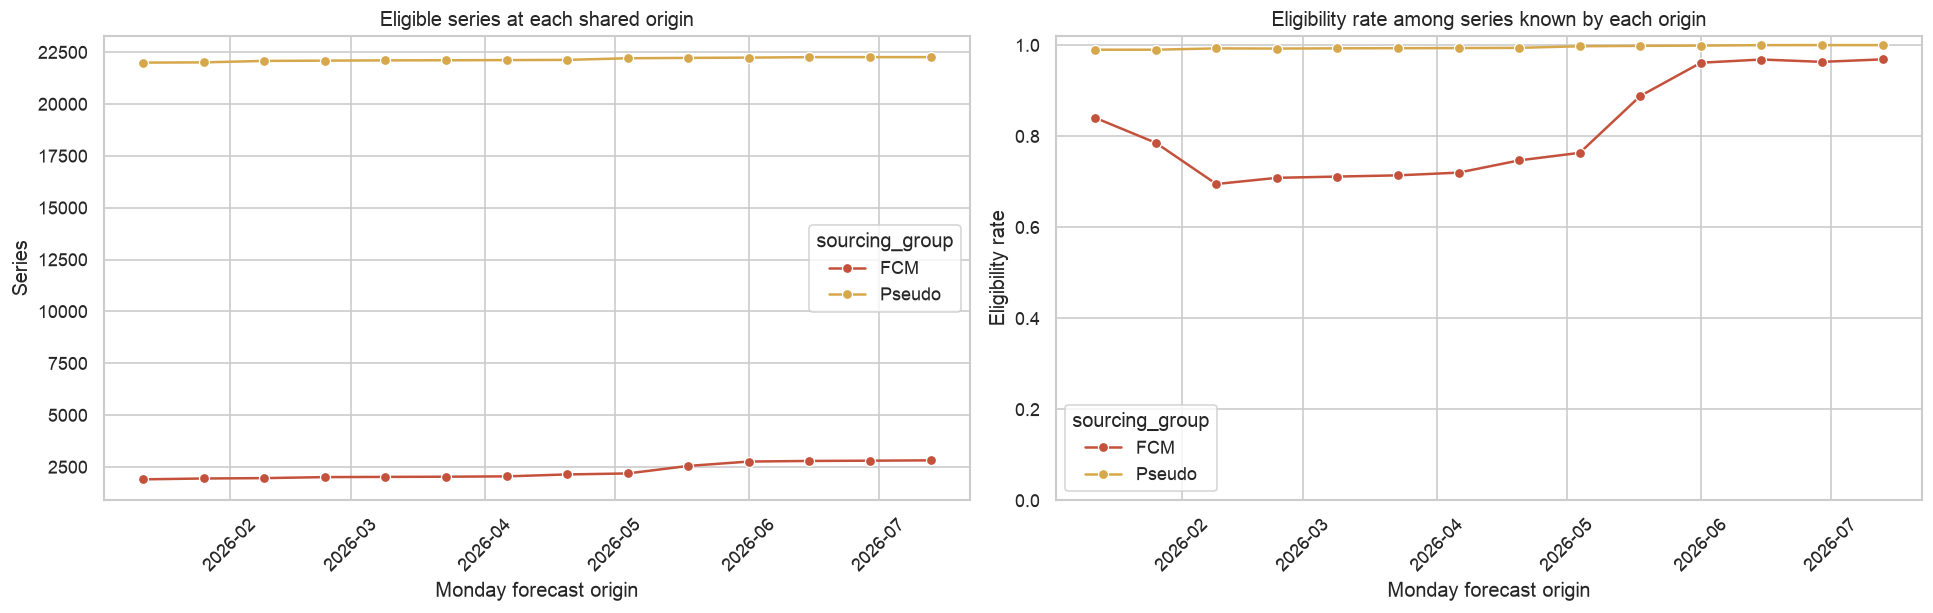

In [13]:
assert len(forecast_origins) > 0
assert (forecast_origins.weekday == 0).all()

schedule = pd.DataFrame({"origin": forecast_origins})
schedule["test_start"] = schedule["origin"]
schedule["test_end_inclusive"] = (
    schedule["origin"] + pd.Timedelta(days=FORECAST_HORIZON_CALENDAR_DAYS - 1)
)
schedule["weekday"] = schedule["origin"].dt.day_name()
display(schedule)

origin_eligibility_rows = []
previous_known_sets = {group_name: set() for group_name in GROUP_ORDER}
previous_eligible_sets = {group_name: set() for group_name in GROUP_ORDER}

for origin_number, origin in enumerate(forecast_origins, start=1):
    training_metrics = series_metrics_at(origin)
    eligible = training_metrics[
        (training_metrics["active_days"] >= DEFAULT_MIN_TRAIN_SIZE)
        & (training_metrics["demand_days"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
    ].copy()

    # Test rows are joined only after the eligible set is fixed.
    test_rows = con.execute("""
    SELECT
        sourcing_group,
        ARTIKEL_ID,
        MARKT_ID,
        COUNT(*) AS observed_test_rows,
        COUNT_IF(demand > 0) AS positive_test_rows
    FROM daily_rows
    WHERE period >= ? AND period < ?
    GROUP BY sourcing_group, ARTIKEL_ID, MARKT_ID
    """, [origin.date(), (origin + pd.Timedelta(days=FORECAST_HORIZON_CALENDAR_DAYS)).date()]).fetchdf()

    eligible_with_test = eligible.merge(
        test_rows,
        on=["sourcing_group", "ARTIKEL_ID", "MARKT_ID"],
        how="left",
    )
    eligible_with_test[["observed_test_rows", "positive_test_rows"]] = (
        eligible_with_test[["observed_test_rows", "positive_test_rows"]].fillna(0)
    )

    for group_name in GROUP_ORDER:
        known_group = training_metrics[training_metrics["sourcing_group"] == group_name]
        eligible_group = eligible_with_test[
            eligible_with_test["sourcing_group"] == group_name
        ]
        known_set = set(map(tuple, known_group[GROUP_COLS].to_numpy()))
        eligible_set = set(map(tuple, eligible_group[GROUP_COLS].to_numpy()))
        if origin_number == 1:
            newly_existing = np.nan
            eligible_new = np.nan
        else:
            additions = eligible_set - previous_eligible_sets[group_name]
            newly_existing = len(additions & previous_known_sets[group_name])
            eligible_new = len(additions - previous_known_sets[group_name])
        origin_eligibility_rows.append({
            "origin": origin,
            "sourcing_group": group_name,
            "known_series": len(known_group),
            "eligible_series": len(eligible_group),
            "eligibility_rate": len(eligible_group) / len(known_group) if len(known_group) else np.nan,
            "newly_eligible_existing_series": newly_existing,
            "eligible_new_series": eligible_new,
            "eligible_with_test_rows": int((eligible_group["observed_test_rows"] > 0).sum()),
            "observed_test_rows": int(eligible_group["observed_test_rows"].sum()),
            "positive_test_rows": int(eligible_group["positive_test_rows"].sum()),
        })
        previous_known_sets[group_name] = known_set
        previous_eligible_sets[group_name] = eligible_set

origin_eligibility = pd.DataFrame(origin_eligibility_rows)
display(origin_eligibility.style.format({
    "known_series": "{:,.0f}", "eligible_series": "{:,.0f}",
    "eligibility_rate": "{:.1%}", "newly_eligible_existing_series": "{:,.0f}",
    "eligible_new_series": "{:,.0f}", "eligible_with_test_rows": "{:,.0f}",
    "observed_test_rows": "{:,.0f}", "positive_test_rows": "{:,.0f}",
}, na_rep="first origin"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.lineplot(
    data=origin_eligibility, x="origin", y="eligible_series", hue="sourcing_group",
    hue_order=GROUP_ORDER, palette=GROUP_COLORS, marker="o", ax=axes[0]
)
sns.lineplot(
    data=origin_eligibility, x="origin", y="eligibility_rate", hue="sourcing_group",
    hue_order=GROUP_ORDER, palette=GROUP_COLORS, marker="o", ax=axes[1]
)
axes[0].set_title("Eligible series at each shared origin")
axes[0].set_ylabel("Series")
axes[1].set_title("Eligibility rate among series known by each origin")
axes[1].set_ylabel("Eligibility rate")
axes[1].set_ylim(0, 1.02)
for ax in axes:
    ax.set_xlabel("Monday forecast origin")
    ax.tick_params(axis="x", rotation=45)
display_figure(fig)

### Information-boundary audit

The selected constants are calibrated once with the OLD later-only reference design. The calendar evaluation still obeys a strict forecast boundary: for every origin, eligibility and model inputs use only rows before that origin, while observed rows in the seven-day test window are joined afterward only to describe scoring capacity.

In [14]:
first_origin_training_last_date = con.execute(
    "SELECT MAX(period) FROM daily_rows WHERE period < ?", [first_origin.date()]
).fetchone()[0]

information_audit = pd.DataFrame([
    {
        "artifact": "Whole-history group/category distributions",
        "information_end": pd.Timestamp(extract_dates["last_date"]),
        "affects_forecast_origin": False,
        "role": "Descriptive reporting only",
    },
    {
        "artifact": "OLD-style (W, k) calibration",
        "information_end": calibration_periods["period"].max(),
        "affects_forecast_origin": False,
        "role": "Offline design calibration on FCM first-window vs later-only reference",
    },
    {
        "artifact": "First calendar origin and eligibility",
        "information_end": pd.Timestamp(first_origin_training_last_date),
        "affects_forecast_origin": True,
        "role": "Uses DATE < first origin",
    },
    {
        "artifact": "Later-origin eligibility",
        "information_end": pd.NaT,
        "affects_forecast_origin": True,
        "role": "Recomputed separately with DATE < that origin",
    },
    {
        "artifact": "Observed rows in each seven-day test window",
        "information_end": pd.NaT,
        "affects_forecast_origin": False,
        "role": "Joined after eligibility; scoring capacity only",
    },
])
display(information_audit)
assert pd.Timestamp(first_origin_training_last_date) < first_origin

,artifact,information_end,affects_forecast_origin,role
0,Whole-history group/category distributions,2026-07-21,False,Descriptive reporting only
1,"OLD-style (W, k) calibration",2026-07-21,False,Offline design calibration on FCM first-window vs later-only reference
2,First calendar origin and eligibility,2026-01-11,True,Uses DATE < first origin
3,Later-origin eligibility,NaT,True,Recomputed separately with DATE < that origin
4,Observed rows in each seven-day test window,NaT,False,Joined after eligibility; scoring capacity only


## 4. Cross-group check at the first calendar origin

The rule is calibrated on FCM, but the resulting evaluation population should still be sensible for Pseudo. This final check keeps the two source groups separate and reports first-origin eligibility, store/product coverage, finite ADI/CV2 shares, and demand-class mix. Pseudo is not allowed to change $(W,k)$; it is inspected only to ensure that the FCM-calibrated rule is not pathological for the longer-history group.

In [15]:
selected_group_diagnostics = selected_group_diagnostics.copy()
selected_group_diagnostics["role"] = np.where(
    selected_group_diagnostics["sourcing_group"] == CALIBRATION_GROUP,
    "calibration group", "validation group"
)
selected_group_diagnostics["near_total_eligibility"] = (
    selected_group_diagnostics["eligibility_rate"] >= LONG_GROUP_NEAR_TOTAL_RATE
).astype("boolean")
selected_group_diagnostics.loc[
    selected_group_diagnostics["sourcing_group"] == CALIBRATION_GROUP,
    "near_total_eligibility",
] = pd.NA

validation_columns = [
    "sourcing_group", "role", "known_series", "eligible_series",
    "eligibility_rate", "store_coverage", "product_coverage",
    "near_total_eligibility",
]
display(selected_group_diagnostics[validation_columns].style.format({
    "known_series": "{:,.0f}", "eligible_series": "{:,.0f}",
    "eligibility_rate": "{:.1%}", "store_coverage": "{:.1%}",
    "product_coverage": "{:.1%}",
}, na_rep="calibration group"))

selected_eligible_metrics = first_origin_metrics[
    (first_origin_metrics["active_days"] >= DEFAULT_MIN_TRAIN_SIZE)
    & (first_origin_metrics["demand_days"] >= MIN_DEMAND_PERIODS_UNTIL_ORIGIN)
].copy()
class_shares = pd.crosstab(
    selected_eligible_metrics["sourcing_group"],
    selected_eligible_metrics["demand_class"],
    normalize="index",
).reindex(index=GROUP_ORDER).fillna(0)

pathology_rows = []
for group_name in GROUP_ORDER:
    group = selected_eligible_metrics[
        selected_eligible_metrics["sourcing_group"] == group_name
    ]
    pathology_rows.append({
        "sourcing_group": group_name,
        "eligible_series": len(group),
        "finite_ADI_share": np.isfinite(group["ADI"]).mean() if len(group) else np.nan,
        "finite_CV2_share": np.isfinite(group["CV2"]).mean() if len(group) else np.nan,
        "represented_classes": group["demand_class"].nunique(),
        "largest_class_share": class_shares.loc[group_name].max() if group_name in class_shares.index else np.nan,
        "median_ADI": group["ADI"].median(),
        "median_CV2": group["CV2"].median(),
        "maximum_daily_demand_kg": group["maximum_daily_demand_kg"].max(),
    })
pathology_checks = pd.DataFrame(pathology_rows)
print("Group-specific checks among first-origin eligible series:")
display(pathology_checks.style.format({
    "eligible_series": "{:,.0f}", "finite_ADI_share": "{:.1%}",
    "finite_CV2_share": "{:.1%}", "represented_classes": "{:,.0f}",
    "largest_class_share": "{:.1%}", "median_ADI": "{:.3f}",
    "median_CV2": "{:.3f}", "maximum_daily_demand_kg": "{:,.1f}",
}))
print("Demand-class shares among eligible series:")
display(class_shares.style.format("{:.1%}"))

long_group_validation = selected_group_diagnostics[
    selected_group_diagnostics["sourcing_group"] == "Pseudo"
]
pathology_by_group = pathology_checks.set_index("sourcing_group")
validation_passed = bool(
    (long_group_validation["eligibility_rate"] >= LONG_GROUP_NEAR_TOTAL_RATE).all()
    and pathology_by_group.loc["Pseudo", "finite_CV2_share"] == 1
    and pathology_by_group.loc["Pseudo", "represented_classes"] > 1
)
print(
    "Cross-group result: "
    + ("PASS — the FCM-calibrated rule remains broad and well-defined for Pseudo."
       if validation_passed else
       "REVIEW REQUIRED — at least one longer-group check failed.")
)

,sourcing_group,role,known_series,eligible_series,eligibility_rate,store_coverage,product_coverage,near_total_eligibility
0,FCM,calibration group,"2,261","1,900",84.0%,97.9%,84.2%,calibration group
1,Pseudo,validation group,"22,221","21,997",99.0%,97.9%,99.7%,True


Group-specific checks among first-origin eligible series:


,sourcing_group,eligible_series,finite_ADI_share,finite_CV2_share,represented_classes,largest_class_share,median_ADI,median_CV2,maximum_daily_demand_kg
0,FCM,"1,900",100.0%,100.0%,4,51.9%,2.651,0.534,20.9
1,Pseudo,"21,997",100.0%,100.0%,4,70.1%,4.717,0.747,280.0


Demand-class shares among eligible series:


demand_class,erratic,intermittent,lumpy,smooth
sourcing_group,,,,
FCM,5.5%,34.6%,51.9%,8.0%
Pseudo,7.9%,20.8%,70.1%,1.1%


Cross-group result: PASS — the FCM-calibrated rule remains broad and well-defined for Pseudo.


In [16]:
display(
    f"Selected (W, k)=({DEFAULT_MIN_TRAIN_SIZE}, {MIN_DEMAND_PERIODS_UNTIL_ORIGIN}); "
    f"first calendar origin: {first_origin:%A, %d %B %Y}; "
    f"origins: {len(forecast_origins)}"
)

'Selected (W, k)=(91, 10); first calendar origin: Monday, 12 January 2026; origins: 14'

A series can enter at a later origin after accumulating enough open and positive-demand rows. It never receives imputed closed-day observations. At each shared Monday origin, all models see the same expanding calendar cutoff and are scored only on existing rows inside the same Monday-through-Sunday test interval.

## 5. Weekday analysis — intentionally disabled

Weekday-pattern analysis is not used to choose the origin or $(W,k)$ in this version. The template below keeps the intended reporting keys, sourcing group and product category, plus the common calendar origin. If re-enabled, it should compute profiles only from pre-origin training data.

In [17]:
# WEEKDAY ANALYSIS DISABLED FOR NOW.
#
# weekday_training = con.execute("""
# SELECT
#     sourcing_group,
#     category_id,
#     category,
#     ARTIKEL_ID,
#     MARKT_ID,
#     DAYOFWEEK(period) AS weekday_number,
#     AVG(demand) AS mean_demand_kg,
#     COUNT(*) AS observed_open_days
# FROM daily_rows
# WHERE period < ?
# GROUP BY
#     sourcing_group, category_id, category,
#     ARTIKEL_ID, MARKT_ID, weekday_number
# """, [first_origin.date()]).fetchdf()
#
# # Reporting must retain both sourcing_group and category. Any later
# # stability comparison must also remain entirely before first_origin.
# weekday_group_category_summary = (
#     weekday_training.groupby(
#         ["sourcing_group", "category", "weekday_number"], observed=True
#     )
#     .agg(
#         series=("ARTIKEL_ID", "size"),
#         median_mean_demand_kg=("mean_demand_kg", "median"),
#     )
#     .reset_index()
# )
# display(weekday_group_category_summary)
